# Walk-forward re-optimization -- does adapting the config over time beat freezing it once?

Self-contained (own data load, own formulas -- nothing imported from `deprecated/` or any
other notebook). Does **not** modify `combined_strategy_sandbox.ipynb` or any lever
notebook -- this is a separate, additional test.

**The gap this addresses**: every lever notebook so far picks ONE config (bucket, DTE,
roll, band width, buffer) once, using the 2022 train crash, then freezes it for the rest
of the project's life. That's a static hedge. This notebook asks: what if the
moneyness/DTE/roll/band/buffer parameters were periodically **re-optimized** using only
the data available up to that point, then applied going forward until the next
re-optimization?

**No forecasting, still.** At every re-optimization date, the grid search only ever sees
data strictly *before* that date -- never future data, never compared against a future
outcome to pick a winner. This is standard walk-forward parameter estimation, not
prediction: at each point in time we're asking "what would have looked best over the
recent past," never "what will happen next."

**Two variants, run side by side** (per explicit instruction to compare rather than
assume one is better):
- **A**: 150 trading-day lookback, re-optimize every 60 trading days (~7 months of
  memory, ~quarterly re-fit).
- **B**: 90 trading-day lookback, re-optimize every 30 trading days (~4.5 months of
  memory, ~monthly re-fit).

**What gets re-optimized, and what doesn't**: Lever 1's `cost_benefit` instrument rule is
a live, bucket-agnostic mechanism already (not a static parameter) -- it's used
unchanged at every trigger, in every variant. What DOES get re-optimized on a rolling
basis is Levers 2-4's parameters: moneyness bucket, target DTE, roll DTE, coverage-band
width, and buffer -- using the exact same grids and gate/composite-score selection logic
as the original lever notebooks, just re-run on a trailing window instead of once on the
2022 crash.

**Selection within one lookback window**: no separate held-out sub-split -- there's only
one trailing window available at each checkpoint. Instead: gate on MaxDD >= -50% (same
floor as before), then rank survivors by composite score (`sharpe + cagr + maxdd`) on
that single window. If nothing survives the gate, fall back to the best composite score
regardless (documented, not hidden).

**Config changes don't force an immediate re-hedge.** A currently-held contract rides
until its own DTE-roll or coverage-band trigger; a config change only governs what
happens at the *next* trigger. This avoids paying an extra, arbitrary transaction cost
purely because the calendar hit a re-optimization date.

Compared against the static combined strategy (20% OTM / 180-DTE / 7-day roll / 10%
band / buffer=1.0, frozen throughout) over the identical walk-forward date range, for a
fair comparison.

In [1]:
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parents[1]
DATA = ROOT / "data"
%matplotlib inline

## Load data (fresh parse, same conventions as `00_foundation_sandbox.ipynb`)

In [2]:
tsla_raw = pd.read_excel(DATA / "Excel3_Underlying_Data.xlsx", sheet_name="TSLA", header=10)
tsla_raw["Date"] = pd.to_datetime(tsla_raw["Date"])
tsla_spot = tsla_raw.set_index("Date")["Close"].sort_index().dropna()

tsll_raw = pd.read_excel(DATA / "TSLL_ohlcv.xlsx", sheet_name="TSLL")
tsll_raw["Date"] = pd.to_datetime(tsll_raw["Date"])
tsll_spot = tsll_raw.set_index("Date")["Close"].sort_index().dropna()

tsla_calls = pd.read_parquet(DATA / "processed" / "TSLA_calls_close.parquet")
tsll_calls = pd.read_parquet(DATA / "processed" / "TSLL_calls_close.parquet")

r_tsla = tsla_spot.pct_change().dropna()
r_tsll = tsll_spot.pct_change().dropna()
dates = r_tsla.index.intersection(r_tsll.index)
r_tsla, r_tsll = r_tsla.loc[dates], r_tsll.loc[dates]
tsla_spot, tsll_spot = tsla_spot.loc[dates], tsll_spot.loc[dates]

print(f"{len(dates):,} trading days, {dates.min().date()} -> {dates.max().date()}")

960 trading days, 2022-08-10 -> 2026-06-08


## Pre-indexed lookups (performance only)

In [3]:
tsla_calls_by_date = {d: g for d, g in tsla_calls.groupby("date")}
tsll_calls_by_date = {d: g for d, g in tsll_calls.groupby("date")}

tsla_price_lookup = {(r.raw_id, r.date): r.px_last for r in tsla_calls.itertuples(index=False)}
tsll_price_lookup = {(r.raw_id, r.date): r.px_last for r in tsll_calls.itertuples(index=False)}

## Fresh formulas -- Black-Scholes delta, rolling vol/beta, contract selection, sizing, risk metrics

In [4]:
R_RF = 0.05
ESTIMATION_WINDOW = 21

MONEYNESS_RANGES = {
    "ATM": (0.95, 1.05),
    "10% OTM": (1.05, 1.15),
    "20% OTM": (1.15, 1.25),
}


def bs_call_delta(S, K, T_years, r, sigma):
    if T_years <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return 1.0 if S > K else 0.01
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T_years) / (sigma * np.sqrt(T_years))
    return float(np.clip(norm.cdf(d1), 0.01, 1.0))


tsla_sigma = (r_tsla.rolling(ESTIMATION_WINDOW).std() * np.sqrt(252)).ffill().bfill()
tsll_sigma = (r_tsll.rolling(ESTIMATION_WINDOW).std() * np.sqrt(252)).ffill().bfill()
beta_tsll_vs_tsla = ((r_tsll.rolling(ESTIMATION_WINDOW).cov(r_tsla)
                      / r_tsla.rolling(ESTIMATION_WINDOW).var()).shift(1)).ffill().bfill()

assert tsla_sigma.isna().sum() == 0 and tsll_sigma.isna().sum() == 0 and beta_tsll_vs_tsla.isna().sum() == 0


def select_contract(calls_by_date, spot_series, date, moneyness_bucket, target_dte, max_dte):
    day = calls_by_date.get(date)
    if day is None or day.empty:
        return None
    lo, hi = MONEYNESS_RANGES[moneyness_bucket]
    s = float(spot_series.loc[date])
    moneyness = day["strike"] / s
    dte = (day["expiry"] - date).dt.days
    mask = (
        (moneyness >= lo) & (moneyness < hi)
        & (dte > 0) & (dte <= max_dte)
        & day["px_last"].notna() & (day["px_last"] > 0)
        & day["px_volume"].notna() & (day["px_volume"] > 0)
    )
    candidates = day[mask]
    if candidates.empty:
        return None
    dte_c = (candidates["expiry"] - date).dt.days
    idx = (dte_c - target_dte).abs().idxmin()
    return candidates.loc[idx]


def size_position(row, spot_val, sigma_val, target_dollar_delta, date):
    if row is None:
        return 0.0, float("inf"), 0.0
    entry = float(row["px_last"])
    T = max((row["expiry"] - date).days / 365.25, 1 / 365)
    delta = bs_call_delta(float(spot_val), float(row["strike"]), T, R_RF, sigma_val)
    n_contracts = target_dollar_delta / (max(delta, 0.01) * 100 * spot_val)
    cost = n_contracts * 100 * entry
    return n_contracts, cost, entry


def cagr(equity):
    n_years = (equity.index[-1] - equity.index[0]).days / 365.25
    end = equity.iloc[-1]
    return -1.0 if end <= 0 or n_years <= 0 else end ** (1 / n_years) - 1


def sharpe(returns, rf=0.0):
    if len(returns) < 2:
        return float("nan")
    excess = returns - rf / 252
    vol = excess.std()
    return float("nan") if vol == 0 else excess.mean() / vol * np.sqrt(252)


def max_drawdown(equity):
    return (equity / equity.cummax() - 1).min()

## Core simulation -- fixed config over a given date range (used both for re-optimization search windows and as a building block)

In [5]:
def simulate_fixed_config(sim_dates, bucket, target_dte, roll_dte, band_width, buffer, notional=1.0):
    """Same cost_benefit + coverage-band + buffer mechanism as combined_strategy_sandbox,
    with every structural parameter fixed for the whole window. Used to score a single
    candidate config over a single lookback window during re-optimization."""
    max_dte = target_dte + 20
    S_incep = float(tsll_spot.loc[sim_dates[0]])
    n_shares = notional / S_incep

    short_pnl = 0.0
    option_pnl = 0.0
    position = None
    S_prev = S_incep
    equity = pd.Series(index=sim_dates, dtype=float)

    def mtm(pos, date):
        spot_series = tsla_spot if pos["underlying"] == "tsla" else tsll_spot
        lookup = tsla_price_lookup if pos["underlying"] == "tsla" else tsll_price_lookup
        if date > pos["expiry"]:
            return max(float(spot_series.loc[date]) - pos["strike"], 0.0)
        px = lookup.get((pos["raw_id"], date))
        return pos["price"] if (px is None or pd.isna(px)) else float(px)

    def current_delta(pos, date):
        spot_series = tsla_spot if pos["underlying"] == "tsla" else tsll_spot
        sigma_series = tsla_sigma if pos["underlying"] == "tsla" else tsll_sigma
        S_pos = float(spot_series.loc[date])
        T = max((pos["expiry"] - date).days / 365.25, 1 / 365)
        return bs_call_delta(S_pos, pos["strike"], T, R_RF, float(sigma_series.loc[date])), S_pos

    for d in sim_dates:
        S_today = float(tsll_spot.loc[d])
        short_pnl += n_shares * (S_prev - S_today)
        S_prev = S_today

        if position is not None:
            px = mtm(position, d)
            option_pnl += position["n"] * 100 * (px - position["price"])
            position["price"] = px

        current_short_dd = n_shares * S_today
        held_dte = (position["expiry"] - d).days if position is not None else -1
        forced_roll = position is None or held_dte < roll_dte

        band_triggered = False
        if position is not None and band_width is not None and not forced_roll:
            delta_now, S_pos_now = current_delta(position, d)
            current_hedge_dd = position["n"] * 100 * delta_now * S_pos_now
            coverage_ratio = current_hedge_dd / current_short_dd if current_short_dd > 0 else 1.0
            if coverage_ratio < (1 - band_width) or coverage_ratio > (1 + band_width):
                band_triggered = True

        if forced_roll or band_triggered:
            beta_t = float(beta_tsll_vs_tsla.loc[d])
            base_dd = notional if forced_roll else current_short_dd
            target_dollar_delta_tsla = buffer * beta_t * base_dd
            target_dollar_delta_tsll = buffer * base_dd

            row_tsla = select_contract(tsla_calls_by_date, tsla_spot, d, bucket, target_dte, max_dte)
            row_tsll = select_contract(tsll_calls_by_date, tsll_spot, d, bucket, target_dte, max_dte)
            n_a, cost_a, entry_a = size_position(row_tsla, float(tsla_spot.loc[d]), float(tsla_sigma.loc[d]), target_dollar_delta_tsla, d)
            n_b, cost_b, entry_b = size_position(row_tsll, float(tsll_spot.loc[d]), float(tsll_sigma.loc[d]), target_dollar_delta_tsll, d)

            chosen = None
            if row_tsla is not None and (row_tsll is None or cost_a <= cost_b):
                chosen = "tsla"
            elif row_tsll is not None:
                chosen = "tsll"

            if chosen == "tsla":
                position = {"underlying": "tsla", "raw_id": row_tsla["raw_id"], "strike": float(row_tsla["strike"]),
                            "expiry": row_tsla["expiry"], "n": n_a, "price": entry_a}
            elif chosen == "tsll":
                position = {"underlying": "tsll", "raw_id": row_tsll["raw_id"], "strike": float(row_tsll["strike"]),
                            "expiry": row_tsll["expiry"], "n": n_b, "price": entry_b}
            else:
                position = None

        equity.loc[d] = notional + short_pnl + option_pnl

    return equity

## Re-optimization -- sequential Lever 2 -> 3 -> 4 grid search, using ONLY data strictly before the as-of date

In [6]:
MONEYNESS_BUCKETS = ["ATM", "10% OTM", "20% OTM"]
TARGET_DTES = [30, 60, 90, 120, 180]
ROLL_DTES = [7, 14, 30]
BAND_WIDTHS = [None, 0.10, 0.25, 0.50]
BUFFERS = [0.5, 1.0, 1.5, 2.0]
MAXDD_FLOOR = -0.50


def _score(eq):
    rets = eq.pct_change().dropna()
    sh, cg, dd = sharpe(rets), cagr(eq), max_drawdown(eq)
    composite = (0 if np.isnan(sh) else sh) + cg + dd
    return sh, cg, dd, composite


def _pick_best(candidates_scores):
    """candidates_scores: list of (candidate, sharpe, cagr, maxdd, composite).
    Gate on MaxDD >= floor, rank survivors by composite; if none survive, fall back to
    best composite regardless (documented simplification -- no separate held-out window
    exists within a single lookback, so this is the practical fallback)."""
    survivors = [c for c in candidates_scores if c[3] >= MAXDD_FLOOR]
    pool = survivors if survivors else candidates_scores
    pool.sort(key=lambda c: c[4], reverse=True)
    return pool[0][0]


def reoptimize(lookback_dates):
    """Runs Lever 2 -> 3 -> 4 sequentially on lookback_dates alone (no future data).
    Returns (bucket, target_dte, roll_dte, band_width, buffer)."""
    # Lever 2: bucket x DTE x roll, band=off, buffer=1.0 (matches original isolated methodology)
    l2_scores = []
    for bucket, target_dte, roll_dte in itertools.product(MONEYNESS_BUCKETS, TARGET_DTES, ROLL_DTES):
        eq = simulate_fixed_config(lookback_dates, bucket, target_dte, roll_dte, None, 1.0)
        sh, cg, dd, comp = _score(eq)
        l2_scores.append(((bucket, target_dte, roll_dte), sh, cg, dd, comp))
    bucket, target_dte, roll_dte = _pick_best(l2_scores)

    # Lever 3: band width, bucket/dte/roll frozen from Lever 2
    l3_scores = []
    for band_width in BAND_WIDTHS:
        eq = simulate_fixed_config(lookback_dates, bucket, target_dte, roll_dte, band_width, 1.0)
        sh, cg, dd, comp = _score(eq)
        l3_scores.append((band_width, sh, cg, dd, comp))
    band_width = _pick_best(l3_scores)

    # Lever 4: buffer, bucket/dte/roll/band frozen from Levers 2-3
    l4_scores = []
    for buffer in BUFFERS:
        eq = simulate_fixed_config(lookback_dates, bucket, target_dte, roll_dte, band_width, buffer)
        sh, cg, dd, comp = _score(eq)
        l4_scores.append((buffer, sh, cg, dd, comp))
    buffer = _pick_best(l4_scores)

    return {"bucket": bucket, "target_dte": target_dte, "roll_dte": roll_dte, "band_width": band_width, "buffer": buffer}

## Walk-forward loop -- re-optimize on a schedule, apply the resulting config going forward

In [7]:
def simulate_walk_forward(all_dates, lookback_days, reopt_freq_days, notional=1.0):
    start_idx = lookback_days
    assert start_idx < len(all_dates), "lookback longer than available history"
    sim_dates = all_dates[start_idx:]

    S_incep = float(tsll_spot.loc[sim_dates[0]])
    n_shares = notional / S_incep

    short_pnl = 0.0
    option_pnl = 0.0
    position = None
    S_prev = S_incep
    equity = pd.Series(index=sim_dates, dtype=float)
    config_log = []
    config = None

    def mtm(pos, date):
        spot_series = tsla_spot if pos["underlying"] == "tsla" else tsll_spot
        lookup = tsla_price_lookup if pos["underlying"] == "tsla" else tsll_price_lookup
        if date > pos["expiry"]:
            return max(float(spot_series.loc[date]) - pos["strike"], 0.0)
        px = lookup.get((pos["raw_id"], date))
        return pos["price"] if (px is None or pd.isna(px)) else float(px)

    def current_delta(pos, date):
        spot_series = tsla_spot if pos["underlying"] == "tsla" else tsll_spot
        sigma_series = tsla_sigma if pos["underlying"] == "tsla" else tsll_sigma
        S_pos = float(spot_series.loc[date])
        T = max((pos["expiry"] - date).days / 365.25, 1 / 365)
        return bs_call_delta(S_pos, pos["strike"], T, R_RF, float(sigma_series.loc[date])), S_pos

    for i, d in enumerate(sim_dates):
        # --- re-optimization checkpoint: uses only data strictly before d ---
        if i % reopt_freq_days == 0:
            lookback_start_idx = start_idx + i - lookback_days
            lookback_dates = all_dates[lookback_start_idx:start_idx + i]
            config = reoptimize(lookback_dates)
            config_log.append({"date": d, **config})

        bucket, target_dte, roll_dte = config["bucket"], config["target_dte"], config["roll_dte"]
        band_width, buffer = config["band_width"], config["buffer"]
        max_dte = target_dte + 20

        S_today = float(tsll_spot.loc[d])
        short_pnl += n_shares * (S_prev - S_today)
        S_prev = S_today

        if position is not None:
            px = mtm(position, d)
            option_pnl += position["n"] * 100 * (px - position["price"])
            position["price"] = px

        current_short_dd = n_shares * S_today
        held_dte = (position["expiry"] - d).days if position is not None else -1
        forced_roll = position is None or held_dte < roll_dte

        band_triggered = False
        if position is not None and band_width is not None and not forced_roll:
            delta_now, S_pos_now = current_delta(position, d)
            current_hedge_dd = position["n"] * 100 * delta_now * S_pos_now
            coverage_ratio = current_hedge_dd / current_short_dd if current_short_dd > 0 else 1.0
            if coverage_ratio < (1 - band_width) or coverage_ratio > (1 + band_width):
                band_triggered = True

        if forced_roll or band_triggered:
            beta_t = float(beta_tsll_vs_tsla.loc[d])
            base_dd = notional if forced_roll else current_short_dd
            target_dollar_delta_tsla = buffer * beta_t * base_dd
            target_dollar_delta_tsll = buffer * base_dd

            row_tsla = select_contract(tsla_calls_by_date, tsla_spot, d, bucket, target_dte, max_dte)
            row_tsll = select_contract(tsll_calls_by_date, tsll_spot, d, bucket, target_dte, max_dte)
            n_a, cost_a, entry_a = size_position(row_tsla, float(tsla_spot.loc[d]), float(tsla_sigma.loc[d]), target_dollar_delta_tsla, d)
            n_b, cost_b, entry_b = size_position(row_tsll, float(tsll_spot.loc[d]), float(tsll_sigma.loc[d]), target_dollar_delta_tsll, d)

            chosen = None
            if row_tsla is not None and (row_tsll is None or cost_a <= cost_b):
                chosen = "tsla"
            elif row_tsll is not None:
                chosen = "tsll"

            if chosen == "tsla":
                position = {"underlying": "tsla", "raw_id": row_tsla["raw_id"], "strike": float(row_tsla["strike"]),
                            "expiry": row_tsla["expiry"], "n": n_a, "price": entry_a}
            elif chosen == "tsll":
                position = {"underlying": "tsll", "raw_id": row_tsll["raw_id"], "strike": float(row_tsll["strike"]),
                            "expiry": row_tsll["expiry"], "n": n_b, "price": entry_b}
            else:
                position = None

        equity.loc[d] = notional + short_pnl + option_pnl

    return equity, pd.DataFrame(config_log)

## Run both variants

In [8]:
eq_A, log_A = simulate_walk_forward(dates, lookback_days=150, reopt_freq_days=60)
print(f"Variant A (150/60): {len(log_A)} re-optimizations, range {eq_A.index.min().date()} -> {eq_A.index.max().date()}")

Variant A (150/60): 14 re-optimizations, range 2023-03-16 -> 2026-06-08


In [9]:
eq_B, log_B = simulate_walk_forward(dates, lookback_days=90, reopt_freq_days=30)
print(f"Variant B (90/30): {len(log_B)} re-optimizations, range {eq_B.index.min().date()} -> {eq_B.index.max().date()}")

Variant B (90/30): 29 re-optimizations, range 2022-12-16 -> 2026-06-08


## Static combined strategy over the SAME date range, for a fair comparison

In [10]:
common_start = max(eq_A.index.min(), eq_B.index.min())
common_dates = dates[dates >= common_start]

eq_static = simulate_fixed_config(common_dates, "20% OTM", 180, 7, 0.10, 1.0)
eq_A_common = eq_A.loc[eq_A.index >= common_start]
eq_B_common = eq_B.loc[eq_B.index >= common_start]

print(f"Common comparison range: {common_dates.min().date()} -> {common_dates.max().date()} ({len(common_dates)} days)")

Common comparison range: 2023-03-16 -> 2026-06-08 (810 days)


## Comparison table

In [11]:
summary = pd.DataFrame([
    {"strategy": "static (frozen)", "sharpe": sharpe(eq_static.pct_change().dropna()), "cagr": cagr(eq_static), "maxdd": max_drawdown(eq_static)},
    {"strategy": "walk-forward A (150/60)", "sharpe": sharpe(eq_A_common.pct_change().dropna()), "cagr": cagr(eq_A_common), "maxdd": max_drawdown(eq_A_common)},
    {"strategy": "walk-forward B (90/30)", "sharpe": sharpe(eq_B_common.pct_change().dropna()), "cagr": cagr(eq_B_common), "maxdd": max_drawdown(eq_B_common)},
])
summary

,strategy,sharpe,cagr,maxdd
0,static (frozen),0.586473,0.217168,-0.423665
1,walk-forward A (150/60),1.139086,0.561905,-0.438756
2,walk-forward B (90/30),1.285840,0.885386,-0.510561


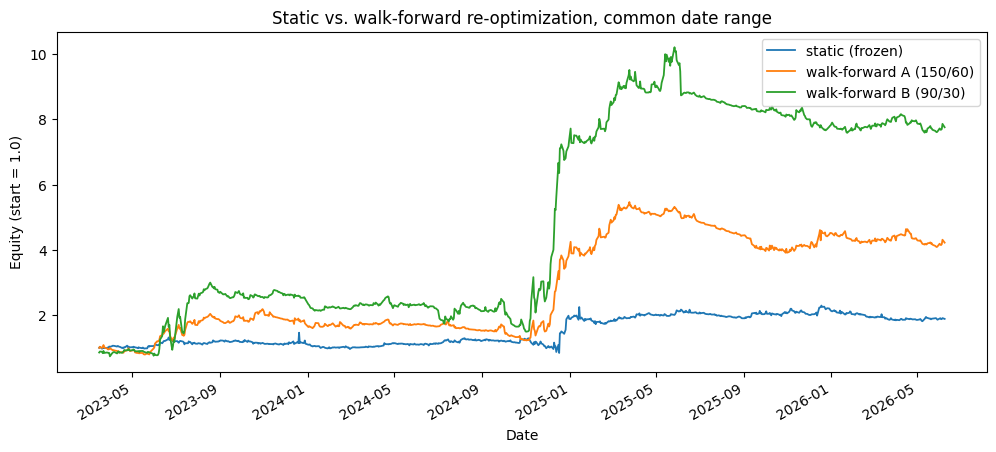

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
eq_static.plot(ax=ax, label="static (frozen)", linewidth=1.3)
eq_A_common.plot(ax=ax, label="walk-forward A (150/60)", linewidth=1.3)
eq_B_common.plot(ax=ax, label="walk-forward B (90/30)", linewidth=1.3)
ax.set_title("Static vs. walk-forward re-optimization, common date range")
ax.set_ylabel("Equity (start = 1.0)")
ax.legend()
plt.show()

## How the config evolved over time

In [13]:
print("Variant A (150/60) config log:")
print(log_A.to_string(index=False))
print("\nVariant B (90/30) config log:")
print(log_B.to_string(index=False))

Variant A (150/60) config log:
      date  bucket  target_dte  roll_dte band_width  buffer
2023-03-16 20% OTM          30        14       None     1.0
2023-06-12 20% OTM          30         7       None     2.0
2023-09-07 20% OTM          30         7       None     1.0
2023-12-01 20% OTM          30         7       None     2.0
2024-02-29     ATM          90        30       None     0.5
2024-05-24 10% OTM          90        30       None     0.5
2024-08-21 20% OTM          60        14       None     1.0
2024-11-14 20% OTM          30         7       None     1.0
2025-02-13 20% OTM          60         7       None     1.0
2025-05-12 20% OTM          90         7       None     2.0
2025-08-07     ATM         120        14       None     0.5
2025-10-31 20% OTM          60        30       None     2.0
2026-01-29 20% OTM          30        14       None     1.0
2026-04-27 20% OTM          90        30       None     0.5

Variant B (90/30) config log:
      date  bucket  target_dte  roll_d

## Sanity checks

In [14]:
assert eq_A.isna().sum() == 0, "variant A equity has NaNs"
assert eq_B.isna().sum() == 0, "variant B equity has NaNs"
assert eq_static.isna().sum() == 0, "static equity has NaNs"
assert len(log_A) > 0 and len(log_B) > 0, "no re-optimizations logged"
assert log_A["bucket"].isin(MONEYNESS_BUCKETS).all() and log_B["bucket"].isin(MONEYNESS_BUCKETS).all()

print("Walk-forward sanity checks passed.")
print("\nFinal comparison:")
print(summary.to_string(index=False))

Walk-forward sanity checks passed.

Final comparison:
               strategy   sharpe     cagr     maxdd
        static (frozen) 0.586473 0.217168 -0.423665
walk-forward A (150/60) 1.139086 0.561905 -0.438756
 walk-forward B (90/30) 1.285840 0.885386 -0.510561
